# 12 — The yield curve and fixed income

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/12_yield_curve_fixed_income.ipynb)

A yield curve is a function of a few factors. The Nelson-Siegel model reads the
Treasury curve, date by date, as a level, a slope and a curvature; three
principal components give the same reading without a parametric form. The
three factors are observed series in levels: the market filters them as a
block (notebook 10) next to an equity return, the vine ties their innovations,
and simulated factors become whole curves at any maturity. From the curves,
discount factors, bond prices and the returns of constant-maturity bonds follow
by arithmetic, so fixed income is priced along the paths instead of being
approximated by a duration times a yield change. Needs `statsmodels`.

Runtime: about 5 minutes.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git[garch,blocks]"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

for pkg in ("arch", "statsmodels"):
    try:
        __import__(pkg)
    except ImportError:
        import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
from cvinemarketgen import load_fred_monthly, load_etf_monthly, Targets, CVineMarket, Paths, NelsonSiegel, PCACurve, curve_returns, iid_tests
from cvinemarketgen.yieldcurve import constant_maturity_return

cvinemarketgen 0.3.0


## Load the curve

Monthly averages of the FRED constant-maturity Treasury yields at 1, 2, 3, 5,
7, 10, 20 and 30 years, in percent, since October 1993 (the 30-year series has
a gap in 2002-2006 that the loader's common-month alignment removes).

The panel is $\mathbf{y}_t = (y_t(\tau_1), \dots, y_t(\tau_M))'$, $M = 8$
maturities $\tau_m \in \{1, 2, 3, 5, 7, 10, 20, 30\}$ years, one row per month
$t$, where $y_t(\tau_m)$ is the mean of the daily FRED values over the month.
The module reads these yields as continuously compounded zero rates in percent,
which is the approximation the pricing below inherits: the FRED series are par
yields of constant-maturity Treasuries, so a bond priced from them is priced off
the par curve rather than a bootstrapped zero curve. `tau` maps each column name
to its maturity in years; `describe` and `tail` show the levels in percent.

In [2]:
ids = ["DGS1", "DGS2", "DGS3", "DGS5", "DGS7", "DGS10", "DGS20", "DGS30"]
Y = load_fred_monthly(ids, start="1993-10", cache=os.path.join(ROOT, "data", "fred_cache.csv"))
tau = {c: float(c[3:]) for c in ids}
print(Y.shape[0], "months,", Y.index.min(), "to", Y.index.max())
Y.tail()

FRED series read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/fred_cache.csv: 396 months, 1993-10 to 2026-09
396 months, 1993-10 to 2026-09


,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
month,,,,,,,,
2026-05,3.792000,3.995000,4.042000,4.145000,4.308500,4.484000,5.025500,5.031000
2026-06,3.909524,4.112857,4.146667,4.210000,4.330952,4.470476,4.957143,4.947619
2026-07,4.050909,4.222727,4.256818,4.330909,4.455455,4.599545,5.110000,5.099091
2026-08,4.031429,4.216190,4.282381,4.384286,4.524762,4.684286,5.217619,5.223810
2026-09,4.261667,4.519167,4.590000,4.677500,4.774167,4.882500,5.319167,5.301667


Three columns of the panel, $y_t(1)$, $y_t(10)$ and $y_t(30)$, over time. The
vertical distance between the 30-year and the 1-year is the slope of the curve,
$y_t(30) - y_t(1)$, positive in most months and negative in the inversions of
2000, 2006-2007 and 2023; the common movement of the three is the level.

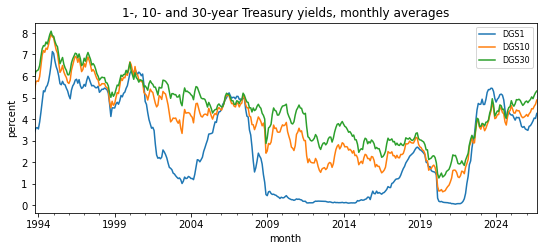

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.5))
Y[["DGS1", "DGS10", "DGS30"]].plot(ax=ax); ax.set_ylabel("percent"); ax.set_title("1-, 10- and 30-year Treasury yields, monthly averages"); ax.legend(fontsize=8); plt.show()

## Nelson-Siegel factors

The curve at date $t$ is

$$y_t(\tau) = L_t + S_t\,\ell_1(\tau) + C_t\,\ell_2(\tau) + e_t(\tau), \qquad
\ell_1(\tau) = \frac{1 - e^{-\lambda\tau}}{\lambda\tau}, \qquad
\ell_2(\tau) = \frac{1 - e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau},$$

with the decay $\lambda = 0.7308$ a year (Diebold and Li's 0.0609 a month, which
puts the maximum of $\ell_2$, the root of $\ell_2'(\tau) = 0$, at 30 months). The
loadings are known functions of $\tau$: the level loads on every maturity alike,
$\ell_1(0) = 1$ and $\ell_1(\infty) = 0$ so the slope loads on the short end,
$\ell_2(0) = \ell_2(\infty) = 0$ so the curvature loads on the middle. For a
fixed $\lambda$ the model is linear in the factors: with $\mathbf{B}$ the
$M \times 3$ matrix whose $m$-th row is $(1, \ell_1(\tau_m), \ell_2(\tau_m))$,
the factors on date $t$ are the least-squares coefficients

$$\hat{\mathbf{f}}_t = (\hat L_t, \hat S_t, \hat C_t)' = (\mathbf{B}'\mathbf{B})^{-1} \mathbf{B}' \mathbf{y}_t,$$

one regression per month with $M - 3 = 5$ degrees of freedom, and the fitted
curve is $\hat{\mathbf{y}}_t = \mathbf{B} \hat{\mathbf{f}}_t$. `NelsonSiegel.fit`
does this for every $t$ and reports the fitting error by maturity,

$$\mathrm{RMSE}(\tau_m) = \Big( \tfrac{1}{T} \sum_t \big( y_t(\tau_m) - \hat y_t(\tau_m) \big)^2 \Big)^{1/2},$$

printed in basis points (percent times 100). The plot shows $\ell_1$ and
$\ell_2$ against maturity, with the constant loading of the level.

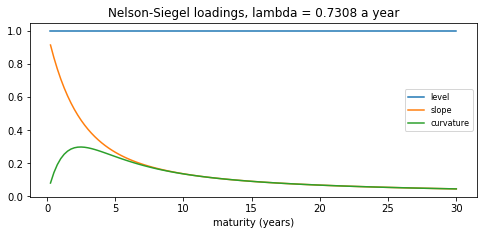

NelsonSiegel(lam=0.7308, maturities=[1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0], n=396)


,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
"fitting error, RMSE (bp)",4.9,8.6,5.4,5.1,7.2,10.3,12.3,8.6


In [4]:
ns = NelsonSiegel(0.7308).fit(Y, maturities=tau)
grid = np.linspace(0.25, 30, 120); L = ns.loadings(grid)
fig, ax = plt.subplots(figsize=(8, 3.2))
for k, name in enumerate(["level", "slope", "curvature"]):
    ax.plot(grid, L[:, k], label=name)
ax.set_xlabel("maturity (years)"); ax.set_title("Nelson-Siegel loadings, lambda = 0.7308 a year"); ax.legend(fontsize=8); plt.show()
print(ns)
ns.rmse.mul(100).round(1).rename("fitting error, RMSE (bp)").to_frame().T

The decay can also be chosen from the data. `NelsonSiegel('auto')` searches
$\lambda$ on a grid from 0.2 to 2.0 by steps of 0.05 (37 values), recomputes
$\hat{\mathbf{f}}_t(\lambda)$ for each candidate and keeps

$$\hat\lambda = \arg\min_{\lambda} \Big( \tfrac{1}{TM} \sum_{t, m} \big( y_t(\tau_m) - \hat y_t(\tau_m; \lambda) \big)^2 \Big)^{1/2},$$

the total root mean squared error over all months and maturities. The cell
prints $\hat\lambda$ and the total RMSE at $\hat\lambda$ and at $0.7308$; the
gain is a couple of basis points, and the fixed decay is kept for the rest of
the notebook because its loadings do not depend on the sample, so factors
estimated on different samples are comparable. `ns.factors.tail()` shows the
last five months of $(\hat L_t, \hat S_t, \hat C_t)$, in percent.

In [5]:
ns_auto = NelsonSiegel("auto").fit(Y, maturities=tau)
print("decay that minimizes the total RMSE:", ns_auto.lam, "| RMSE (bp):", round(float(np.sqrt((ns_auto.rmse ** 2).mean()) * 100), 1),
      "vs", round(float(np.sqrt((ns.rmse ** 2).mean()) * 100), 1), "at 0.7308")
ns.factors.tail().round(3)

decay that minimizes the total RMSE: 0.5 | RMSE (bp): 6.6 vs 8.2 at 0.7308


,level,slope,curvature
month,,,
2026-05,5.140,-0.859,-2.864
2026-06,5.028,-0.720,-2.306
2026-07,5.190,-0.672,-2.553
2026-08,5.324,-0.839,-2.711
2026-09,5.368,-0.945,-1.604


The factors have direct readings in yields, and the plot checks them. Since
$\ell_1(\infty) = \ell_2(\infty) = 0$, the level is the limit of the curve,
$L_t = \lim_{\tau \to \infty} y_t(\tau)$, compared here with $y_t(10)$. Since
$\ell_1(0) = 1$ and $\ell_2(0) = 0$, the short rate is $y_t(0) = L_t + S_t$, so
$-S_t = y_t(\infty) - y_t(0)$ is the long minus short spread, compared with
$y_t(10) - y_t(1)$. The curvature is compared with a butterfly,
$2\,y_t(3) - y_t(1) - y_t(30)$, which loads on the middle of the curve as
$\ell_2$ does. Each panel overlays the factor and its proxy.

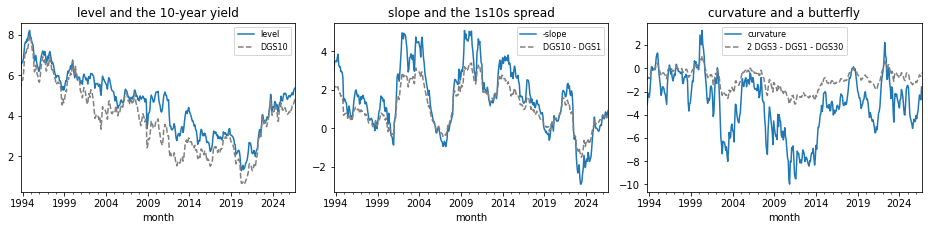

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
ns.factors["level"].plot(ax=axes[0], label="level"); Y["DGS10"].plot(ax=axes[0], color="grey", ls="--", label="DGS10"); axes[0].legend(fontsize=8); axes[0].set_title("level and the 10-year yield")
(-ns.factors["slope"]).plot(ax=axes[1], label="-slope"); (Y["DGS10"] - Y["DGS1"]).plot(ax=axes[1], color="grey", ls="--", label="DGS10 - DGS1"); axes[1].legend(fontsize=8); axes[1].set_title("slope and the 1s10s spread")
ns.factors["curvature"].plot(ax=axes[2], label="curvature"); (2 * Y["DGS3"] - Y["DGS1"] - Y["DGS30"]).plot(ax=axes[2], color="grey", ls="--", label="2 DGS3 - DGS1 - DGS30"); axes[2].legend(fontsize=8); axes[2].set_title("curvature and a butterfly")
plt.tight_layout(); plt.show()

The level tracks the long end, minus the slope tracks the 1s10s spread, and the
curvature a butterfly: the factors are the usual reading of the curve, with
the advantage that they return a full curve at any maturity.

## The PCA benchmark

Principal components of the eight yields' levels. With $\bar{\mathbf{y}}$ the
sample mean and $\mathbf{S} = \frac{1}{T-1} \sum_t (\mathbf{y}_t - \bar{\mathbf{y}})(\mathbf{y}_t - \bar{\mathbf{y}})'$
the sample covariance, the eigendecomposition $\mathbf{S} = \mathbf{V} \boldsymbol{\Lambda} \mathbf{V}'$,
eigenvalues $\lambda_1 \ge \dots \ge \lambda_M$, gives the scores and the reconstruction

$$\mathbf{f}_t = \mathbf{V}_K' (\mathbf{y}_t - \bar{\mathbf{y}}), \qquad
\hat{\mathbf{y}}_t = \bar{\mathbf{y}} + \mathbf{V}_K \mathbf{f}_t, \qquad
\text{share of variance of component } k = \frac{\lambda_k}{\sum_j \lambda_j},$$

with $\mathbf{V}_K$ the first $K = 3$ eigenvectors, each signed so that the
30-year maturity loads positively. The reconstruction is the best rank-$K$
approximation of the panel in the least-squares sense, and its RMSE is printed
in basis points. Three components explain more than 99.9 percent of the
variance and their vectors have the shapes of a level, a slope and a curvature;
the loadings are estimated rather than imposed, which is the benchmark's
advantage, and they are defined only at the eight observed maturities, which
is its limit for pricing: a bond's cash flows fall between them.

pc1    0.9431
pc2    0.0537
pc3    0.0026
pc4    0.0003


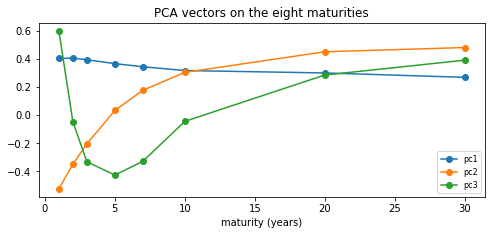

RMSE of the 3-component reconstruction (bp): 4.6


In [7]:
pc = PCACurve(3).fit(Y)
print(pc.explained.round(4).head(4).to_string())
fig, ax = plt.subplots(figsize=(8, 3.2))
pc.loadings().set_index(pd.Index(list(tau.values()), name="maturity (years)")).plot(ax=ax, marker="o"); ax.set_title("PCA vectors on the eight maturities"); ax.legend(fontsize=8); plt.show()
print("RMSE of the 3-component reconstruction (bp):", round(float(np.sqrt(((pc.curve(pc.factors) - Y) ** 2).values.mean()) * 100), 1))

## The factors as a block, SPY alongside

Level, slope and curvature are persistent series in levels with a long-run
relation between them (the slope and the curvature are bounded, the level
wanders). SPY's monthly return comes along over the same 396 months since
1993. The block filter is the vector error-correction model on
$\mathbf{f}_t = (L_t, S_t, C_t)'$,

$$\Delta \mathbf{f}_t = \mathbf{c} + \boldsymbol{\alpha} \boldsymbol{\beta}' \mathbf{f}_{t-1} + \sum_{i=1}^{q} \boldsymbol{\Gamma}_i \Delta \mathbf{f}_{t-i} + \boldsymbol{\eta}_t,$$

where $\boldsymbol{\Pi} = \boldsymbol{\alpha}\boldsymbol{\beta}'$ has rank $r$,
the number of stationary linear combinations $\boldsymbol{\beta}' \mathbf{f}_t$.
The Johansen trace test decides $r$: with $\hat\lambda_1 \ge \dots \ge \hat\lambda_p$
the eigenvalues of the reduced-rank regression of $\Delta \mathbf{f}_t$ on
$\mathbf{f}_{t-1}$ (both corrected for the lagged differences and the constant,
`det_order=0`), the statistic for the hypothesis of rank at most $r$ is

$$\mathrm{LR}(r) = -T \sum_{i=r+1}^{p} \ln(1 - \hat\lambda_i),$$

compared with its 5 percent critical value; the rank is the smallest $r$ that
is not rejected. The table gives the statistics and critical values for
$q = 1$ and $q = 2$ lagged differences: one relation with either choice. The
block is then a VECM with one lagged difference, SPY keeps its AR(1)-GARCH, and
the vine carries the dependence between the four residual columns.

In [8]:
spy = load_etf_monthly(["SPY"], start="1993-10", cache=os.path.join(ROOT, "data", "etf_cache_spy.csv"))   # SPY since 1993, its own cache
data = ns.factors.join(spy, how="inner")
print(data.shape[0], "months,", data.index.min(), "to", data.index.max())
from statsmodels.tsa.vector_ar.vecm import coint_johansen
rows = {}
for q in (1, 2):
    j = coint_johansen(data[["level", "slope", "curvature"]].values, det_order=0, k_ar_diff=q)
    rej = j.lr1 > j.cvt[:, 1]; rank = int(np.argmin(rej)) if not rej.all() else 3
    rows[f"q = {q}"] = {"trace, r = 0": j.lr1[0], "crit 5%": j.cvt[0, 1], "trace, r <= 1": j.lr1[1], "crit 5% ": j.cvt[1, 1], "trace, r <= 2": j.lr1[2], "crit 5%  ": j.cvt[2, 1], "rank": rank}
pd.DataFrame(rows).T.round(2)

ETF returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/etf_cache_spy.csv: 396 months, 1993-10 to 2026-09
396 months, 1993-10 to 2026-09


,"trace, r = 0",crit 5%,"trace, r <= 1",crit 5%,"trace, r <= 2",crit 5%,rank
q = 1,39.54,29.8,10.00,15.49,2.94,3.84,1.0
q = 2,36.49,29.8,8.79,15.49,2.61,3.84,1.0


The market has four variables and its residual layer four columns. For the
block, `BlockVECM` estimates the VECM above with $r$ from the trace test and
$q = 1$, and returns the standardized innovations

$$\varepsilon_{k,t} = \frac{\hat\eta_{k,t}}{\hat\sigma_k}, \qquad k \in \{L, S, C\},$$

each divided by its own standard deviation only, so that the correlations
between the three are left to the vine. For SPY, the AR(1)-GARCH(1,1) filter
$r_t = c + \phi r_{t-1} + \epsilon_t$, $\epsilon_t = \sigma_t \varepsilon_t$,
$\sigma_t^2 = \omega + a\,\epsilon_{t-1}^2 + b\,\sigma_{t-1}^2$, returns
$\varepsilon_t = \epsilon_t / \sigma_t$. The generator is then fitted on the
residual layer as on any history: targets are its sample mean, volatility,
skewness and kurtosis per column (kurtosis floored at $3.1 + 2\gamma_1^2$, the
boundary of the Johnson SU family) and its correlation matrix; families are
selected per edge from the exceedance-correlation signature and the BIC, SPY as
the central node; parameters are calibrated to the correlations. `dynamics_report`
lists each variable's model, its parameter count and $\mathrm{BIC} = k \ln n - 2\ell$
on the data scale; the three rows of the block share one likelihood.

In [9]:
t = Targets.from_history(data)
t0 = time.time()
cv = CVineMarket(t, central="SPY", families="auto", dynamics={("level", "slope", "curvature"): "vecm(q=1)", "SPY": "ar1-garch"}).fit()
print(f"fit: {time.time() - t0:.0f} s")
cv.dynamics_report

fit: 81 s


,model,n_params,loglik,bic
level,"VECM(r=1, q=1)",20,-210.116248,539.759514
slope,"VECM(r=1, q=1)",20,-210.116248,539.759514
curvature,"VECM(r=1, q=1)",20,-210.116248,539.759514
SPY,"AR(1)-GARCH(1,1)",5,711.3193,-1392.744172


The estimated block. The cointegrating vector $\boldsymbol{\beta}$ is
normalized on the level, so the stationary combination is
$\boldsymbol{\beta}' \mathbf{f}_t = L_t + \beta_S S_t + \beta_C C_t$, a long-end
yield net of the shape of the curve; the adjustment vector $\boldsymbol{\alpha}$
says how each factor's change responds to last month's disequilibrium,
$\Delta f_{k,t} \ni \alpha_k (\boldsymbol{\beta}' \mathbf{f}_{t-1} - \text{const})$;
$\sigma_k$ is the innovation standard deviation of each factor equation, in
percent a month. The parameter count is
$2pr - r^2 + p^2 q + p + p$ (loadings and cointegrating vectors net of the
normalisation, short-run matrices, constants, variances) with $p = 3$, and the
BIC is on the same scale as SPY's.

In [10]:
blk = cv.dynamics.models[("level", "slope", "curvature")]
print(blk.name, "| BIC", round(blk.bic, 1))
pd.DataFrame({"beta (cointegrating vector)": blk.beta[:, 0], "alpha (adjustment)": blk.alpha[:, 0], "sigma (innovation sd)": blk.sigma}, index=blk.columns).round(3)

VECM(r=1, q=1) | BIC 539.8


,beta (cointegrating vector),alpha (adjustment),sigma (innovation sd)
level,1.000,0.002,0.197
slope,1.567,-0.021,0.305
curvature,-1.481,0.032,0.652


### The residual layer of the block

The standardized innovations $\varepsilon_{k,t}$ of the three factors, tested
for independence over time with $m = 20$ lags. The Ljung-Box statistic on a
series $x_t$ with sample autocorrelations $\hat\rho_j$ is

$$Q(m) = n(n+2) \sum_{j=1}^{m} \frac{\hat\rho_j^2}{n - j} \;\sim\; \chi^2_m \text{ under independence},$$

applied to $\varepsilon_{k,t}$ (`lb_z`, autocorrelation left by the filter) and
to $\varepsilon_{k,t}^2$ (`lb_z2`, variance clustering); the ARCH-LM statistic
is $n R^2$ from the regression of $\varepsilon_{k,t}^2$ on its $m$ lags, also
$\chi^2_m$. The table gives $p$-values: below 0.05 rejects independence in that
dimension. The correlation between the three columns, and with SPY's
innovation, is what the vine carries.

In [11]:
z = blk.filter()
pd.DataFrame({c: iid_tests(z[c].values) for c in z.columns}).round(3)

,level,slope,curvature
lb_z,0.410,0.412,0.004
lb_z2,0.782,0.000,0.000
arch_lm,0.827,0.001,0.004


The targets of the vine, and the vine. `fit_targets.corr` is the sample
correlation matrix $\hat{\Sigma}$ of the residual layer, the matrix the
calibration reproduces. `edges` lists, tree by tree, each pair-copula
$c_{ik|1:k-1}$ of the C-vine with SPY as the central node: the family and its
rotation (0, 90, 180 or 270 degrees), or a mixture $w C_1 + (1-w) C_2$ when the
exceedance-correlation curve of the pair changes sign, and the calibrated
parameters. Tail coefficients read off the parameters: for a Gumbel
$\lambda_U = 2 - 2^{1/\theta}$ in the corner the rotation selects, for a
Clayton $\lambda_L = 2^{-1/\theta}$, zero for a Gaussian.

In [12]:
print(cv.fit_targets.corr.round(2)); cv.edges

            SPY  level  slope  curvature
SPY        1.00   0.03  -0.02       0.06
level      0.03   1.00  -0.69       0.15
slope     -0.02  -0.69   1.00      -0.47
curvature  0.06   0.15  -0.47       1.00


,tree,edge,selected family,parameters
0,1,"level , SPY",clayton 0° + gumbel 270°,"w=0.79, theta=(0.231, 1.575)"
1,1,"slope , SPY",clayton 0° + clayton 90°,"w=0.07, theta=(9.249, 0.112)"
2,1,"curvature , SPY",gaussian 0°,theta=0.064
3,2,"slope , level | SPY",gumbel 270°,theta=2.044
4,2,"curvature , level | SPY",gumbel 0°,theta=1.103
5,3,"curvature , slope | SPY, level",gumbel 270°,theta=1.501


## Simulated curves

`simulate_paths` draws the residual layer from the calibrated vine, one
four-column vector per path and month ($1{,}000 \times 24$ draws), and pushes
each column back through its filter from the last observed state. For the
block that is the recursion in levels, started from the last two observed
months,

$$\Delta \mathbf{f}^{(s)}_t = \hat{\mathbf{c}} + \hat{\boldsymbol{\alpha}} \hat{\boldsymbol{\beta}}' \mathbf{f}^{(s)}_{t-1} + \hat{\boldsymbol{\Gamma}}_1 \Delta \mathbf{f}^{(s)}_{t-1} + \mathrm{diag}(\hat\sigma_L, \hat\sigma_S, \hat\sigma_C)\, \boldsymbol{\varepsilon}^{(s)}_t, \qquad
\mathbf{f}^{(s)}_t = \mathbf{f}^{(s)}_{t-1} + \Delta \mathbf{f}^{(s)}_t,$$

for SPY the GARCH recursion, so the factors come back in percent and SPY in
returns. `ns.curve` then maps the factor paths to yields at the fitted
maturities, or at any others, by
$y^{(s)}_t(\tau) = L^{(s)}_t + S^{(s)}_t \ell_1(\tau) + C^{(s)}_t \ell_2(\tau)$,
with no fitting error added. The fans show, month by month, the quantiles
across paths of $y^{(s)}_t(10)$ and of the spread $y^{(s)}_t(10) - y^{(s)}_t(2)$;
the table gives the 5, 50 and 95 percent quantiles of the 2-, 10- and 30-year
yields at months 1, 12 and 24.

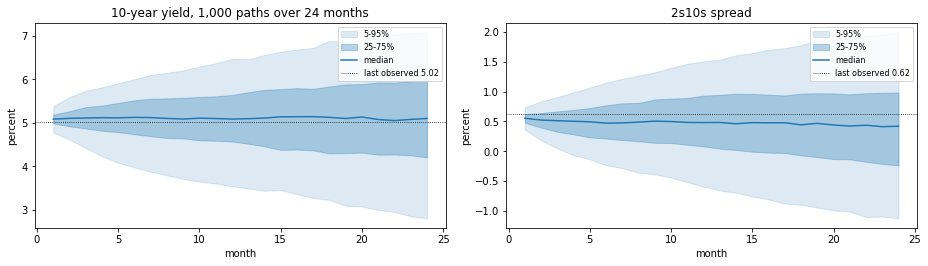

DGS2             DGS10             DGS30            
    0.05  0.50  0.95  0.05  0.50  0.95  0.05  0.50  0.95
t                                                       
1   4.23  4.53  4.85  4.77  5.08  5.38  4.96  5.29  5.57
12  2.60  4.60  6.41  3.54  5.09  6.47  3.85  5.28  6.59
24  1.81  4.64  7.56  2.80  5.10  7.09  3.12  5.25  7.30

In [13]:
P = cv.simulate_paths(1000, 24, seed=1)
F_cols = ["level", "slope", "curvature"]
PF = Paths(P.array[:, :, [P.assets.index(c) for c in F_cols]], F_cols, layer="factors")
C = ns.curve(PF)                                    # Paths of yields at the eight maturities
C2 = ns.curve(PF, tau=[2, 10])
last_curve = ns.curve(ns.factors.iloc[[-1]]).iloc[0]
def fan(ax, X, last, title, ylabel="percent"):
    q = np.quantile(X, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0); h = X.shape[1]
    ax.fill_between(range(1, h + 1), q[0], q[4], color="tab:blue", alpha=0.15, label="5-95%"); ax.fill_between(range(1, h + 1), q[1], q[3], color="tab:blue", alpha=0.3, label="25-75%")
    ax.plot(range(1, h + 1), q[2], color="tab:blue", label="median"); ax.axhline(last, color="black", lw=0.8, ls=":", label=f"last observed {last:.2f}")
    ax.set_xlabel("month"); ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(fontsize=8)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
fan(axes[0], C.array[:, :, C.assets.index("DGS10")], last_curve["DGS10"], "10-year yield, 1,000 paths over 24 months")
fan(axes[1], C2.array[:, :, 1] - C2.array[:, :, 0], last_curve["DGS10"] - last_curve["DGS2"], "2s10s spread")
plt.tight_layout(); plt.show()
C.to_frame().groupby("t")[["DGS2", "DGS10", "DGS30"]].quantile([0.05, 0.5, 0.95]).unstack().round(2).loc[[1, 12, 24]]

The same paths read across maturities: at months 12 and 24, the median and
the 5 and 95 percent quantiles across paths of $y^{(s)}_m(\tau_j)$ for each of
the eight maturities, against the last fitted curve $\mathbf{B} \hat{\mathbf{f}}_T$.
Every simulated curve is a Nelson-Siegel curve, so the fans are smooth in
maturity by construction.

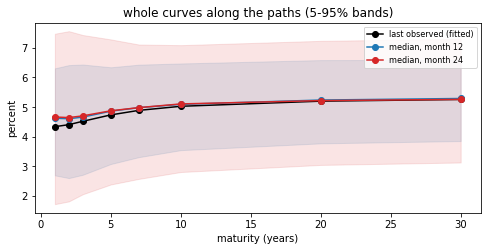

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(list(tau.values()), last_curve.values, color="black", marker="o", label="last observed (fitted)")
for m, col in [(12, "tab:blue"), (24, "tab:red")]:
    q = np.quantile(C.array[:, m - 1, :], [0.05, 0.5, 0.95], axis=0)
    ax.plot(list(tau.values()), q[1], color=col, marker="o", label=f"median, month {m}"); ax.fill_between(list(tau.values()), q[0], q[2], color=col, alpha=0.12)
ax.set_xlabel("maturity (years)"); ax.set_ylabel("percent"); ax.set_title("whole curves along the paths (5-95% bands)"); ax.legend(fontsize=8); plt.show()

## Fixed income along the paths

Prices follow from the curve. With yields in percent and continuous
compounding, the discount factor at maturity $\tau$ on the curve of factors
$\mathbf{f}$ is $P(\tau; \mathbf{f}) = \exp(-\tau\, y(\tau; \mathbf{f}) / 100)$;
a bond of maturity $\tau$ paying a coupon $c$ percent a year in $n = 2$
instalments at dates $t_k = k/n$, $k = 1, \dots, n\tau$, is worth
$B(c, \tau; \mathbf{f}) = \frac{c}{n} \sum_k P(t_k; \mathbf{f}) + 100\, P(\tau; \mathbf{f})$
per 100 of face, and the par yield is the coupon that prices it at 100,

$$c^{\ast}(\tau; \mathbf{f}) = n \cdot 100\, \frac{1 - P(\tau; \mathbf{f})}{\sum_{k=1}^{n\tau} P(t_k; \mathbf{f})}.$$

A constant-maturity bond index of maturity $\tau$ buys the par bond each month
(coupon $c^\ast_t = c^\ast(\tau; \mathbf{f}_t)$, price 100) and values it a month
later, $\delta = 1/12$, on the new curve with its remaining cash flows at
$t_k - \delta$:

$$r^{cm}_{t+1}(\tau) = \frac{1}{100} \left[ \frac{c^\ast_t}{n} \sum_{k=1}^{n\tau} P(t_k - \delta; \mathbf{f}_{t+1}) + 100\, P(\tau - \delta; \mathbf{f}_{t+1}) \right] - 1,$$

carry, roll-down and the price change together. `curve_returns` applies this on
every path and month, $\mathbf{f}_t$ being the previous month's simulated factors
(the last observed factors `F0` for the first month); `kind='zero'` gives the
zero-coupon alternative $P(\tau - \delta; \mathbf{f}_{t+1}) / P(\tau; \mathbf{f}_t) - 1$.
The returns are monthly, in decimals, like SPY's; `summary` pools them over
paths and months and the cell annualizes the mean ($\times 12$) and the
volatility ($\times \sqrt{12}$), leaving skewness and kurtosis as pooled
monthly moments.

In [15]:
F0 = ns.factors.iloc[-1].values
R = curve_returns(PF, [2, 5, 10, 30], ns, F0, kind="par")
summ = R.summary(); summ["mean"] *= 12; summ["vol"] *= np.sqrt(12)
print("simulated constant-maturity bond returns, annualized mean and vol, pooled skewness and kurtosis")
summ.round(3)

simulated constant-maturity bond returns, annualized mean and vol, pooled skewness and kurtosis


,mean,vol,skew,kurt
2y,0.045,0.014,0.215,5.016
5y,0.049,0.035,0.301,5.624
10y,0.053,0.057,0.652,7.166
30y,0.064,0.108,1.134,10.051


Cumulative returns along each path, $\prod_{j \le t} (1 + r^{cm}_j(\tau)) - 1$,
and their 5, 50 and 95 percent quantiles across paths at months 12 and 24, for
the four maturities. The median is close to the carry; the spread of the
quantiles grows with maturity, which is duration.

In [16]:
cum = R.cumulative()
print("cumulative return quantiles at 12 and 24 months")
pd.concat({m: pd.DataFrame(np.quantile(cum.array[:, m - 1, :], [0.05, 0.5, 0.95], axis=0), index=["5%", "50%", "95%"], columns=R.assets) for m in (12, 24)}).round(3)

cumulative return quantiles at 12 and 24 months


2y     5y    10y    30y
12 5%   0.018 -0.016 -0.054 -0.128
   50%  0.044  0.046  0.047  0.045
   95%  0.073  0.127  0.181  0.320
24 5%   0.060  0.007 -0.040 -0.144
   50%  0.093  0.101  0.102  0.104
   95%  0.128  0.208  0.307  0.562

The pooled Pearson correlation, over all paths and months, between the monthly
return of each constant-maturity bond and SPY's simulated monthly return on the
same path and month: the bond-equity correlation the market produces, which
comes from the dependence between the factors' innovations and SPY's residual
through the vine and from the block's dynamics. In symbols, $\mathrm{corr}\big(r^{cm}_{s,t}(\tau),\, r^{SPY}_{s,t}\big)$ over all pairs $(s, t)$ of path and month.

In [17]:
spy_sim = P.array[:, :, P.assets.index("SPY")]
pd.Series({a: np.corrcoef(R.array[:, :, j].ravel(), spy_sim.ravel())[0, 1] for j, a in enumerate(R.assets)}, name="corr of monthly return with SPY (paths)").round(3)

2y    -0.072
5y    -0.070
10y   -0.065
30y   -0.059
Name: corr of monthly return with SPY (paths), dtype: float64

## Against the history and the duration proxy

The same pricing on the historical factors gives the realized monthly returns
of the constant-maturity indices since 1993: $r^{cm}_t(\tau)$ evaluated on the
consecutive fitted factors $(\hat{\mathbf{f}}_{t-1}, \hat{\mathbf{f}}_t)$, a
series the data do not provide directly. The table sets the annualized mean
($\times 12$) and volatility ($\times \sqrt{12}$), skewness and kurtosis
(pandas' excess kurtosis plus 3) of the historical returns against the pooled
moments of the simulated ones from the previous section, maturity by maturity.

In [18]:
Fh = ns.factors.values
Rh = pd.DataFrame({f"{t}y": constant_maturity_return(Fh[:-1], Fh[1:], float(t), ns) for t in [2, 5, 10, 30]}, index=ns.factors.index[1:])
hist = pd.DataFrame({"mean": Rh.mean() * 12, "vol": Rh.std() * np.sqrt(12), "skew": Rh.skew(), "kurt": Rh.kurt() + 3})
comp = pd.concat({"history": hist, "paths": summ[["mean", "vol", "skew", "kurt"]].set_axis(hist.index)}, axis=1)
comp.round(3)

history                       paths                      
       mean    vol   skew   kurt   mean    vol   skew    kurt
2y    0.031  0.016  0.514  3.786  0.045  0.014  0.215   5.016
5y    0.042  0.036  0.045  3.411  0.049  0.035  0.301   5.624
10y   0.046  0.060  0.209  4.419  0.053  0.057  0.652   7.166
30y   0.052  0.121  0.711  7.608  0.064  0.108  1.134  10.051

The duration proxy is the first-order version of $r^{cm}$. Expanding the price
around an unchanged yield, $dB/B \approx -D\, dy$, gives

$$r^{proxy}_t(10) = \frac{y_{t-1}(10)}{100}\, \delta \;-\; D\, \frac{y_t(10) - y_{t-1}(10)}{100}, \qquad D = 8,$$

carry minus a modified duration times the change of the constant-maturity
yield, the form used when only a yield series is available. It drops the
roll-down (the bond is valued at $\tau - \delta$, not $\tau$), the convexity
(the second-order term $\tfrac12 \mathcal{C}\,(dy)^2$, positive), the change of
$D$ with the level of yields, and it uses the change of one yield where $r^{cm}$
uses the change of the whole curve at the cash-flow dates. The cell measures
the gap on the historical 10-year: the correlation of the two series, the
RMSE of the proxy in percent a month, and their annualized means, whose
difference is the roll-down and convexity the proxy gives up.

In [19]:
y10 = ns.curve(ns.factors, tau=[10.0]).iloc[:, 0]
D = 8.0                                               # modified duration of a 10-year par bond near 4 percent
proxy = (y10.shift(1) / 100 / 12 - D * (y10 - y10.shift(1)) / 100).dropna()
exact = Rh["10y"].loc[proxy.index]
pd.Series({"correlation": np.corrcoef(exact, proxy)[0, 1], "RMSE of the proxy (monthly, pct)": float(np.sqrt(((exact - proxy) ** 2).mean()) * 100),
           "mean exact (annualized, pct)": exact.mean() * 1200, "mean proxy (annualized, pct)": proxy.mean() * 1200}, name="10-year: exact return vs duration proxy").round(3)

correlation                         0.997
RMSE of the proxy (monthly, pct)    0.151
mean exact (annualized, pct)        4.617
mean proxy (annualized, pct)        4.083
Name: 10-year: exact return vs duration proxy, dtype: float64

## Save

`cv.save` writes the fitted market to JSON: the targets, the Johnson SU
parameters $(\gamma_i, \xi_i, \delta_i, \lambda_i)$ of each residual column,
the edges of the vine with their families and parameters, and the dynamics
with the block's last observed state, so that `load` can simulate without
refitting. The Nelson-Siegel object is saved alongside as its decay, maturities
and column names. The last line reloads the market and simulates three paths
of six months as a check.

In [20]:
import json
cv.save("curve_market.json")
with open("curve_ns.json", "w") as f:
    json.dump(ns.to_dict(), f)
CVineMarket.load("curve_market.json").simulate_paths(3, 6, seed=2)

Paths(n_paths=3, horizon=6, assets=4, returns)

## Where to go next

Any curve with a parametric loading fits the same way: a corporate curve as a
spread over the Treasury factors, a foreign curve as a second block. The
Nelson-Siegel factors here are dynamic in the sense of Diebold and Li, without
the arbitrage-free adjustment of the affine version; that adjustment, and
credit curves, are the next steps.